In [21]:
!pip install stable_baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [22]:
import numpy as np
import pandas as pd
from gymnasium import Env
from gymnasium.spaces import Box, Discrete
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt

In [47]:
import matplotlib.pyplot as plt

In [96]:
class AdvancedMicrogridEnv(Env):
    """
    a microgrid environment inspired by research on drl for microgrid energy management.
    the environment simulates a community battery, renewable generation, load demand,
    and grid pricing.
    """

    def __init__(self, parameters):
        super(AdvancedMicrogridEnv, self).__init__()

        for parameter, value in parameters.items():
          if parameter == 'wind':
            self.wind_generation = value
          elif parameter == 'pv':
            self.pv_generation = value
          elif parameter == 'load':
            self.load_demand = value
          elif parameter == 'price':
            self.price = value

        self.action_space = Discrete(4)

        # define observation space:
        # [battery soc, pv generation, wind generation, load demand, electricity price, time-of-day]

        self.observation_space = Box(low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)

        # parameters:
        # simulate one day with hourly steps

        self.max_steps = 24*7
        self.current_step = 0

        # battery parameters:
        # arbitrary units

        self.battery_capacity = 100.0
        # initial soc (50%)
        self.battery_soc = 0.5
        # units per step if charging
        self.charge_rate = 10.0
        # units per step if discharging
        self.discharge_rate = 10.0


        # cost parameters:
        self.grid_buy_cost_multiplier = 1.0
        # assume selling gives less revenue than buying cost
        self.grid_sell_revenue_multiplier = 0.8

        self.reset()

    def step(self, action):
        # update time: assume each step is one hour
        self.time_of_day = (self.current_step % 24) / 24.0

        # update renewable generation, load demand, and electricity price
        pv = self.pv_generation[self.current_step]
        wind = self.wind_generation[self.current_step]
        load = self.load_demand[self.current_step]
        price = self.price[self.current_step]

        # initialize cost/reward for this step
        reward = 0.0

        #calculate excess load needed to fulfill
        load = load-pv-wind #positive if more energy need, negative if we generated excess

        # process the chosen action
        if action == 0:
          #charge battery
          if load < 0:
            self.battery_soc = min(self.battery_soc+(-1*load)/self.battery_capacity,
                                   1,
                                   self.battery_soc+self.charge_rate)
          elif load > 0:
            reward = -100 * load

        elif action == 1:
          #discharge battery
          discharge = min(self.battery_soc * self.battery_capacity,
                          self.discharge_rate * self.battery_capacity,
                          max(0,load))
          self.battery_soc -= discharge/self.battery_capacity
          load -= discharge
          if load > 0:
            reward = -100 * load

        elif action == 2:
          #buy from grid
          bought = max(load,0)
          reward = -bought * price

        elif action == 3:
          if load > 0:
            reward = -100 * load
          else:
            reward = load * price



        # assemble the state vector
        state = np.array([
            self.battery_soc,
            pv,
            wind,
            load,
            price,
            self.time_of_day
        ], dtype=np.float32)

        self.current_step += 1
        done = self.current_step >= self.max_steps

        info = {}
        return state, reward, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        # reset battery to 50%
        self.battery_soc = 0.5
        self.time_of_day = 0.0
        pv = self.pv_generation[self.current_step]
        wind = self.wind_generation[self.current_step]
        load = self.load_demand[self.current_step]
        price = self.price[self.current_step]

        state = np.array([
            self.battery_soc,
            pv,
            wind,
            load,
            price,
            self.time_of_day
        ], dtype=np.float32)

        return state, {}

In [97]:
#rye microgrid data
df = pd.read_csv('/content/train.csv')
df.head()

,time,pv_production,wind_production,consumption,spot_market_price,precip_1h:mm,precip_type:idx,prob_precip_1h:p,clear_sky_rad:W,clear_sky_energy_1h:J,...,t_50m:C,relative_humidity_50m:p,dew_point_50m:C,wind_speed_50m:ms,wind_dir_50m:d,t_100m:C,relative_humidity_100m:p,dew_point_100m:C,wind_speed_100m:ms,wind_dir_100m:d
0,2020-01-01 13:00:00,0.0,40.59,26.514689,0.28969,0.0,0.0,1.0,10.0,64826.0,...,8.4,60.7,1.3,8.4,246.3,8.3,60.3,1.0,10.4,247.3
1,2020-01-01 14:00:00,0.0,67.86,28.326960,0.29561,0.0,0.0,1.0,0.0,8961.1,...,8.4,61.6,1.5,8.0,252.3,8.4,60.7,1.2,10.0,252.1
2,2020-01-01 15:00:00,0.0,116.68,23.682207,0.30044,0.0,0.0,1.0,0.0,0.0,...,8.5,60.3,1.3,9.6,254.1,8.4,59.6,1.0,11.7,253.8
3,2020-01-01 16:00:00,0.0,120.22,25.354782,0.29975,0.0,0.0,1.0,0.0,0.0,...,8.4,63.9,2.0,12.1,254.6,8.3,63.4,1.7,14.3,254.2
4,2020-01-01 17:00:00,0.0,109.86,23.861942,0.29650,0.0,0.0,1.0,0.0,0.0,...,7.2,78.9,3.8,11.7,249.5,7.1,77.9,3.5,13.9,249.7


In [98]:
parameters={}
parameters["pv"]=np.array(df['pv_production'])[:24*7]
parameters["wind"]=np.array(df['wind_production'])[:24*7]
parameters["load"]=np.array(df['consumption'])[:24*7]
parameters["price"]=np.array(df['spot_market_price'])[:24*7]

mg = AdvancedMicrogridEnv(parameters)

In [99]:
check_env(mg)

model = DQN("MlpPolicy", mg, verbose=1)

# Train the model
model.learn(total_timesteps=10000)  # Adjust timesteps based on your needs

# Save the model
model.save("dqn_microgrid")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 168       |
|    ep_rew_mean      | -1.39e+05 |
|    exploration_rate | 0.362     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 1929      |
|    time_elapsed     | 0         |
|    total_timesteps  | 672       |
| train/              |           |
|    learning_rate    | 0.0001    |
|    loss             | 764       |
|    n_updates        | 142       |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 168       |
|    ep_rew_mean      | -1.37e+05 |
|    exploration_rate | 0.05      |
| time/               |           |
|    episodes         | 8         |
|    fps              | 1713      |
|    time_elapsed     | 0         |
|    total_timesteps  | 1344      |
| trai

In [100]:
def test_dqn(model, env, episodes=1):
    """
    Tests a trained DQN model on the given environment and visualizes the results.

    :param model_path: Path to the trained DQN model.
    :param env: The environment instance.
    :param test_data: Dictionary containing 'wind', 'pv', 'load', and 'price' test data.
    :param episodes: Number of episodes to run.
    """
    # Load the trained model

    for episode in range(episodes):
        state, _ = env.reset()
        done = False
        states, actions, rewards, battery_soc = [], [], [], []

        while not done:
            action, _ = model.predict(state, deterministic=True)
            next_state, reward, done, _, _ = env.step(action)

            states.append(state)
            actions.append(action)
            rewards.append(reward)
            battery_soc.append(state[0])

            state = next_state

        # Visualization
        time_steps = np.arange(len(actions))
        fig, ax1 = plt.subplots(figsize=(10, 5))

        ax1.set_xlabel("Time Step")
        ax1.set_ylabel("Battery SOC", color='tab:blue')
        ax1.plot(time_steps, battery_soc, label='Battery SOC', color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')

        ax2 = ax1.twinx()
        ax2.set_ylabel("Reward", color='tab:red')
        ax2.plot(time_steps, rewards, label='Reward', color='tab:red', linestyle='dashed')
        ax2.tick_params(axis='y', labelcolor='tab:red')

        plt.title(f"DQN Microgrid Test - Episode {episode + 1}")
        fig.tight_layout()
        plt.show()

        # Plot actions separately
        plt.figure(figsize=(10, 3))
        plt.step(time_steps, actions, where='mid', label='Actions')
        plt.xlabel("Time Step")
        plt.ylabel("Action")
        plt.xticks()
        plt.yticks([0, 1, 2, 3], ['Charge', 'Discharge', 'Buy', 'Sell'])
        plt.title(f"Actions Taken - Episode {episode + 1}")
        plt.legend()
        plt.show()

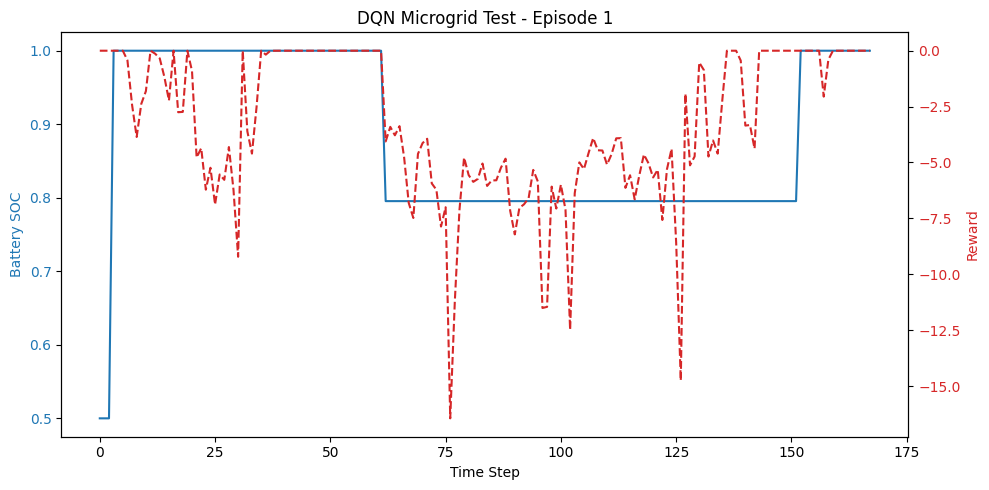

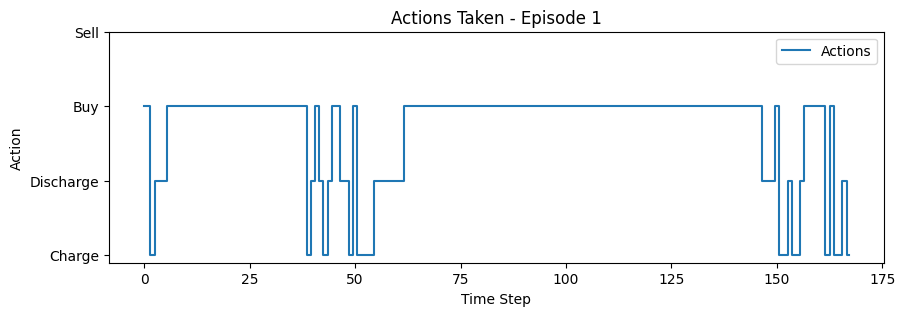

In [101]:
test_dqn(model, mg)